In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

Text(0.5, 1.0, 'Custom Colormap')

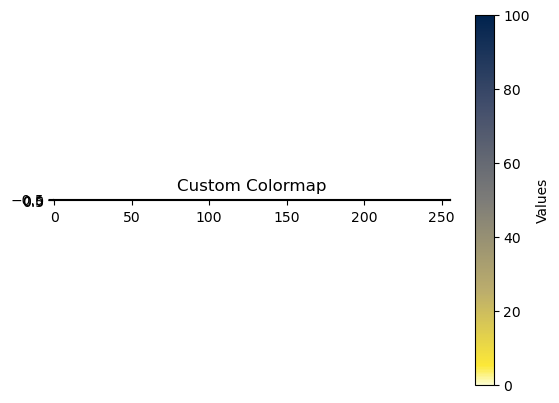

In [2]:
# Customiized colormap

colors = [(0.99,0.99,0.80),(0.99, 0.91, 0.217772),(0.736488, 0.680629, 0.424028),(0.488697, 0.485318, 0.471008),(0.263738, 0.307831, 0.422789),(0,0.135112,0.304751,1)] 
positions = [0.0,0.05,0.25,0.5,0.75,1]  # Corresponding positions

# Create the custom colormap
new_spec = LinearSegmentedColormap.from_list('new_spec', list(zip(positions, colors)))

# Display the colormap
plt.imshow(np.linspace(0, 100, 256).reshape(1, -1), cmap=new_spec)
plt.colorbar(label='Values')
plt.title('Custom Colormap')

In [5]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)
dfib['ISOTIME'] = pd.to_datetime(dfib['ISOTIME'])
dfib_track=pd.read_csv("../IB_track_file/ibtracs_ERA5_track_pair.csv",keep_default_na=False) # IB track type info
ib_et_id=dfib_track[dfib_track.end_type=='ET'].TID.values
ib_land_id=dfib_track[dfib_track.end_type=='LAND'].TID.values

In [6]:
def myround20(number):
    return 20 * round(number / 20)

def myround5(number):
    return 5 * round(number / 5)

In [ ]:
# Prepare evolution path data for plotting
dfib_all=dfib[(dfib.MeanRad>0)].copy()
dfib_all['index']=np.arange(0,len(dfib_all),1)
fst=dfib_all.groupby('TID')['index'].first()
dfib_all['lapse']=dfib_all.groupby(['TID'],group_keys=False)['index'].apply(lambda x: x-list(x)[0])
dfib_all['MeanRadrd']=myround20(dfib_all['MeanRad'])
dfib_all['MSLP']=np.where(dfib_all['MSLP']==0, dfib_all['WMO_PRES'], dfib_all['MSLP'])

epid=dfib_all[(dfib_all['lapse']==0) & (dfib_all.MSLP<990) & (dfib_all.LON>176)].TID.unique()
dfib_all=dfib_all[~dfib_all['TID'].isin(epid)].reset_index(drop=True)
dfib_all_et = dfib_all
x1=dfib_all_et.groupby('lapse')['MSLP'].mean().to_numpy()
y1=dfib_all_et.groupby('lapse')['MeanRad'].mean().to_numpy()
z1=dfib_all_et.groupby('lapse')['MSLP'].count().to_numpy()

In [9]:
# Determine TC evolution pathways
peak_ind=dfib_all.groupby('TID')['MSLP'].idxmin()
dfib_peak=dfib_all.loc[peak_ind].reset_index(drop=True)
end_ind=dfib_all.groupby('TID')['lapse'].idxmax()
dfib_end=dfib_all.loc[end_ind].reset_index(drop=True)
maxisze_ind=dfib_all.groupby('TID')['MeanRad'].idxmax()
dfib_maxsize=dfib_all.loc[maxisze_ind].reset_index(drop=True)


wd_id=dfib_peak[(dfib_peak.MSLP>=970) & (dfib_maxsize.MeanRad<105)].TID.unique()
wg_id=dfib_peak[(dfib_peak.MSLP>=970) & (dfib_maxsize.MeanRad>=105)].TID.unique()
sd_e_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad<105) & (dfib_end.MeanRad>dfib_peak.MeanRad)].TID.unique()
sd_s_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad<105) & (dfib_end.MeanRad<=dfib_peak.MeanRad)].TID.unique()
sg_e_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad>=105) & (dfib_end.MeanRad>dfib_peak.MeanRad) ].TID.unique()
sg_s_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad>=105) & (dfib_end.MeanRad<=dfib_peak.MeanRad) ].TID.unique()    
other_id=dfib_peak[~dfib_peak.TID.isin(np.concatenate([wd_id,wg_id,sd_e_id,sd_s_id,sg_e_id,sg_s_id]))].TID.unique()

wp_id=dfib_track[dfib_track.basin_label=='WP'].TID.unique()
na_id=dfib_track[dfib_track.basin_label=='NA'].TID.unique()

id_lists = [
    ('WD', wd_id),
    ('WG', wg_id),
    ('SD-E', sd_e_id),
    ('SD-S', sd_s_id),
    ('SG-E', sg_e_id),
    ('SG-S', sg_s_id),
]

mslp_rad = {}

for name, id_list in id_lists:
    df_subset = dfib_all[dfib_all['TID'].isin(id_list)]
    peak_ind = df_subset.groupby('TID')['MSLP'].idxmin()
    peak_mslp = df_subset.loc[peak_ind]['MSLP'].mean()
    peak_mrad = df_subset.loc[peak_ind]['MeanRad'].mean()
    fst_mslp = df_subset.groupby('TID')['MSLP'].first().mean()
    fst_mrad = df_subset.groupby('TID')['MeanRad'].first().mean()
    lst_mslp = df_subset.groupby('TID')['MSLP'].last().mean()
    lst_mrad = df_subset.groupby('TID')['MeanRad'].last().mean()
    mslp_rad[name] = {
        'peak_mslp': peak_mslp,
        'peak_mrad': peak_mrad,
        'fst_mslp': fst_mslp,
        'fst_mrad': fst_mrad,
        'lst_mslp': lst_mslp,
        'lst_mrad': lst_mrad
    }

In [ ]:
# dfib_int=dfib_all[dfib_all.TID.isin(np.intersect1d(wg_id, na_id))][['SEASON', 'NAME', 'MeanRad', 'MSLP', 'TID']]
# dfib_int.groupby('TID')[['SEASON', 'NAME', 'MeanRad', 'MSLP']].last()

In [ ]:
# Prepare Intensity-Size distribution data for plotting
dfib_na=dfib[(dfib.MeanRad>0) & (dfib.MSLP>0) & (dfib.BASIN=='NA')].copy()
dfib_na['MeanRadrd']=myround20(dfib_na['MeanRad'])
dfib_na['MSLPrd']=myround5(dfib_na['MSLP'])
totalct=len(dfib_na)
dfnc_na=dfib_na.groupby(['MeanRadrd','MSLPrd'],as_index=True).agg({'LON':'count'}).unstack()
dfnc_na=dfnc_na/totalct

dfib_wp=dfib[(dfib.MeanRad>0) & (dfib.MSLP>0) & (dfib.BASIN=='WP')].copy()
dfib_wp['MeanRadrd']=myround20(dfib_wp['MeanRad'])
dfib_wp['MSLPrd']=myround5(dfib_wp['MSLP'])
totalct=len(dfib_wp)
dfnc_wp=dfib_wp.groupby(['MeanRadrd','MSLPrd'],as_index=True).agg({'LON':'count'}).unstack()
dfnc_wp=dfnc_wp/totalct

/tmp/ipykernel_2195993/2577240450.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('../figures/size/figure5.jpg', dpi=500, bbox_inches='tight')
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


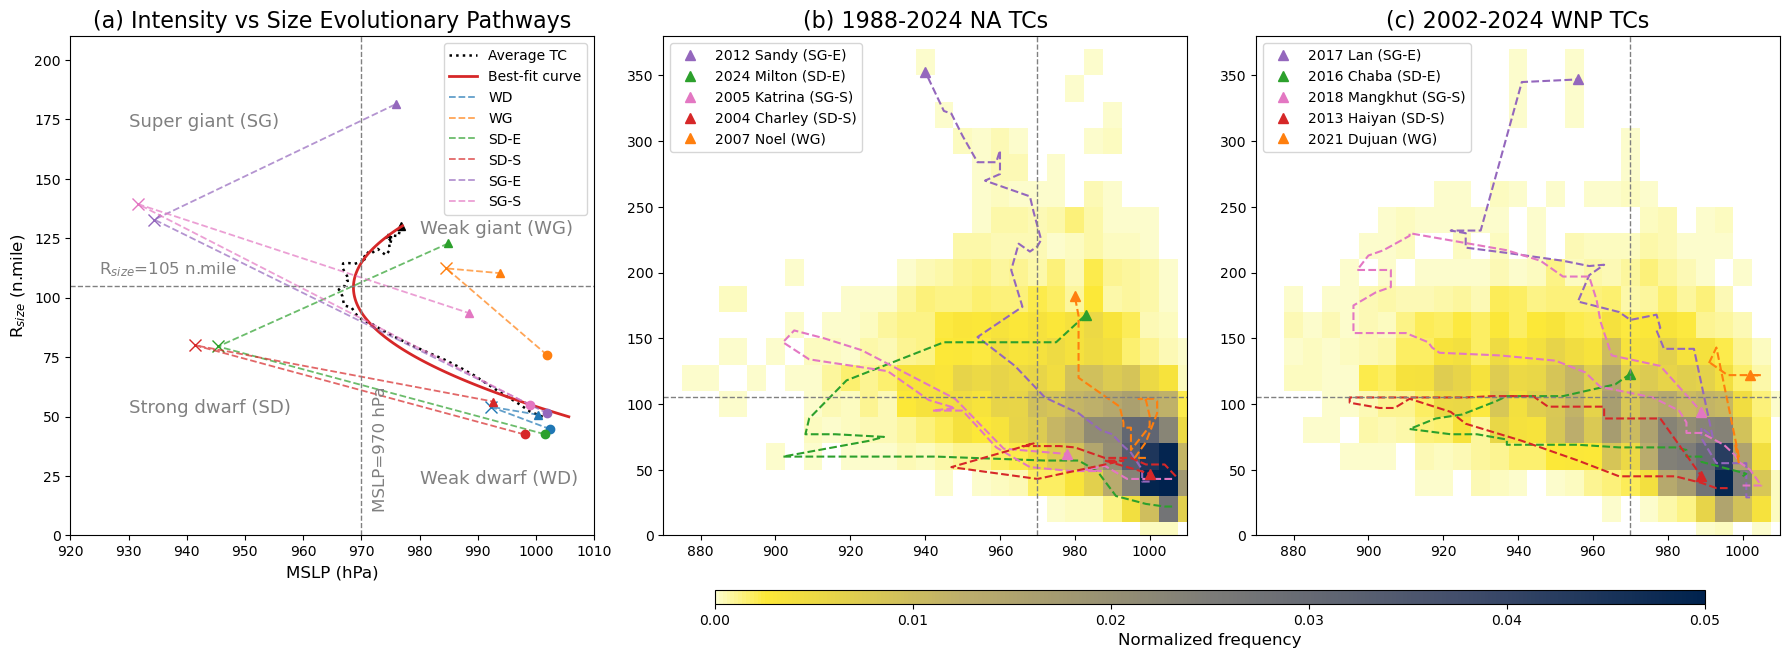

In [ ]:
# Plot Figure 5
fig = plt.figure(figsize=(18,6),layout="tight")
ax1 = fig.add_subplot(1,3,1)
tcid=dfib_all.TID.unique()
line1=ax1.plot(x1[:48], y1[:48], 'k',ls='dotted',lw=1.8,label='Average TC')
ax1.plot(x1[47], y1[47],'^',ms=6,c='k')
# plot a best-fit polynomial curve
coeffs = np.polyfit(y1[:48], x1[:48], 2)
poly_eq = np.poly1d(coeffs)
y_fit = np.linspace(min(y1[:48]), max(y1[:48]), 100)
x_fit = poly_eq(y_fit)
ax1.plot(x_fit, y_fit, c='tab:red', label='Best-fit curve',lw=2)

#plot results in mslp_rad
color_list=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:pink']
count=0
for name, stats in mslp_rad.items():
    ax1.plot(stats['fst_mslp'], stats['fst_mrad'], 'o', ms=6, alpha=1, c=color_list[count])
    ax1.plot(stats['peak_mslp'], stats['peak_mrad'], 'x', ms=8, alpha=1, c=color_list[count])
    ax1.plot(stats['lst_mslp'], stats['lst_mrad'], '^', ms=6, alpha=1, c=color_list[count])
    #plot lines connecting start, peak, end
    ax1.plot([stats['fst_mslp'], stats['peak_mslp'], stats['lst_mslp']],
             [stats['fst_mrad'], stats['peak_mrad'], stats['lst_mrad']],
             linestyle='--', color=color_list[count], alpha=0.7, lw=1.3, label=f'{name}')
    count+=1

ax1.set_xlim(920,1010)
ax1.set_ylim(0,210)
# draw vertical line at MSLP=970 and horizontal line at MeanRad=105
ax1.axvline(x=970, color='gray', linestyle='--', lw=1)
ax1.axhline(y=105, color='gray', linestyle='--', lw=1)
ax1.text(972, 10, 'MSLP=970 hPa', rotation=90, va='bottom', color='gray',fontsize=12)
ax1.text(925, 108, 'R$_{size}$=105 n.mile', va='bottom', color='gray',fontsize=12)
ax1.text(980, 20, 'Weak dwarf (WD)', va='bottom', color='gray',fontsize=13)
ax1.text(980, 125, 'Weak giant (WG)', va='bottom', color='gray',fontsize=13)
ax1.text(930, 50, 'Strong dwarf (SD)', va='bottom', color='gray',fontsize=13)
ax1.text(930, 170, 'Super giant (SG)', va='bottom', color='gray',fontsize=13)
ax1.set_xlabel('MSLP (hPa)', fontsize=12)
ax1.set_ylabel('R$_{size}$ (n.mile)', fontsize=12)
ax1.set_title('(a) Intensity vs Size Evolutionary Pathways', fontsize=16)
ax1.legend(fontsize=10)

ax1 = fig.add_subplot(1,3,2)
dft=dfib_all[(dfib_all.NAME=='SANDY') & (dfib_all.SEASON==2012)] # 2012 Sandy
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:purple',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:purple', label='2012 Sandy (SG-E)')

dft=dfib_all[(dfib_all.NAME=='MILTON') & (dfib_all.SEASON==2024)] # 2024 Milton
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:green',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:green', label='2024 Milton (SD-E)')

dft=dfib_all[(dfib_all.NAME=='KATRINA') & (dfib_all.SEASON==2005)] # 2005 Katrina
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:pink',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:pink', label='2005 Katrina (SG-S)')

dft=dfib_all[(dfib_all.NAME=='CHARLEY') & (dfib_all.SEASON==2004)] # 2004 Charley
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:red',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1],'^',ms=7,c='tab:red', label='2004 Charley (SD-S)')
dft=dfib_all[(dfib_all.NAME=='NOEL') & (dfib_all.SEASON==2007)] # 2007 Noel
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:orange',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1],'^',ms=7,c='tab:orange', label='2007 Noel (WG)')
y = dfnc_na.index.values  # MeanRadrd (y-axis)
x = dfnc_na.columns.levels[1].values  # WSrd (x-axis)
X, Y = np.meshgrid(x, y)
Z = dfnc_na.values
pcm = ax1.pcolormesh(X, Y, Z, shading='auto', cmap=new_spec, vmin=0, vmax=0.05)

ax1.set_title('(b) 1988-2024 NA TCs', fontsize=16)
ax1.legend(fontsize=10,loc='upper left')
ax1.axvline(x=970, color='gray', linestyle='--', lw=1)
ax1.axhline(y=105, color='gray', linestyle='--', lw=1)
ax1.set_xlim(870,1010)
ax1.set_ylim(0,380)

ax1 = fig.add_subplot(1,3,3)
dft=dfib_all[(dfib_all.NAME=='LAN') & (dfib_all.SEASON==2017)] # 2017 Lan
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:purple',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:purple', label='2017 Lan (SG-E)')

dft=dfib_all[(dfib_all.NAME=='CHABA') & (dfib_all.SEASON==2016)] # 2016 Chaba
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:green',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:green', label='2016 Chaba (SD-E)')

dft=dfib_all[(dfib_all.NAME=='MANGKHUT') & (dfib_all.SEASON==2018)] # 2018 Mangkhut
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:pink',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1], '^',ms=7,c='tab:pink', label='2018 Mangkhut (SG-S)')
dft=dfib_all[(dfib_all.NAME=='HAIYAN') & (dfib_all.SEASON==2013)] # 2013 Haiyan
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:red',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1],'^',ms=7,c='tab:red', label='2013 Haiyan (SD-S)')

dft=dfib_all[(dfib_all.NAME=='DUJUAN') & (dfib_all.SEASON==2021)] # 2021 Dujuan
ax1.plot(dft.MSLP, dft.MeanRad,'--',c='tab:orange',lw=1.5)
ax1.plot(dft.MSLP.iloc[-1], dft.MeanRad.iloc[-1],'^',ms=7,c='tab:orange', label='2021 Dujuan (WG)')

ax1.set_title('(c) 2002-2024 WNP TCs', fontsize=16)
ax1.legend(fontsize=10,loc='upper left')
ax1.axvline(x=970, color='gray', linestyle='--', lw=1)
ax1.axhline(y=105, color='gray', linestyle='--', lw=1)
ax1.set_xlim(870,1010)
ax1.set_ylim(0,380)
y = dfnc_wp.index.values  # MeanRadrd (y-axis)
x = dfnc_wp.columns.levels[1].values  # WSrd (x-axis)
X, Y = np.meshgrid(x, y)
Z = dfnc_wp.values
pcm = ax1.pcolormesh(X, Y, Z, shading='auto', cmap=new_spec, vmin=0, vmax=0.05)
cbar_ax = fig.add_axes([0.4, -0.015, 0.55, 0.023])  # [left, bottom, width, height]
cbar=fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='Normalized frequency')
cbar.ax.xaxis.label.set_size(12)
fig.savefig('../figures/figure5.jpg', dpi=500, bbox_inches='tight')